In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
torch.manual_seed(42)

### ANN Architecture

***input feature : 28x28 => 784***

***layers***

1) 128 neurons , relu

2) 64 neurons , relu

3) 10 neurons , softmax

In [4]:
df_train=pd.read_csv("datasets/fashionMNST/fashion-mnist_train.csv")
df_test=pd.read_csv("datasets/fashionMNST/fashion-mnist_test.csv")

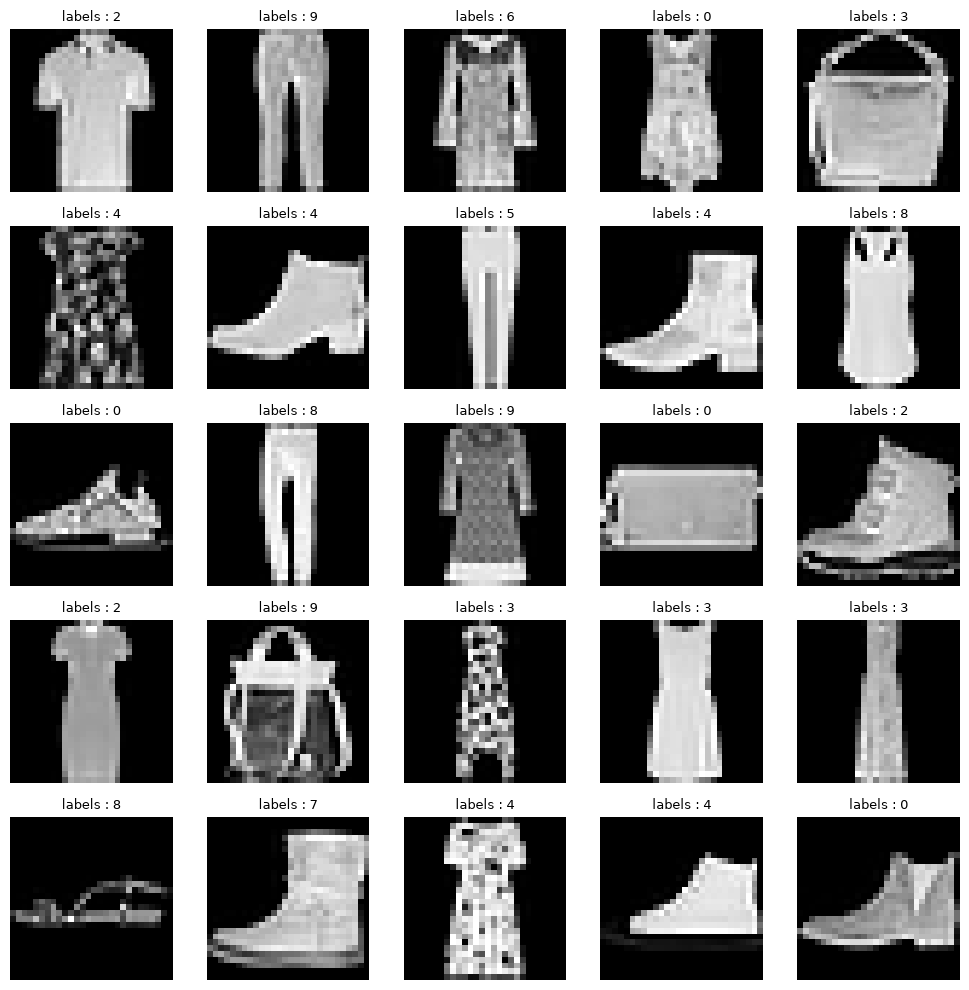

In [5]:
# plot some of the images
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i,ax in enumerate(axes.flat):
    idx = np.random.randint(len(df_train))

    label = int(df_train.iloc[idx, 0])
    image = df_train.iloc[idx, 1:].to_numpy().reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"labels : {df_train.iloc[i,0]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
x_train=df_train.iloc[:,1:].values
y_train=df_train.iloc[:,0].values

x_test=df_test.iloc[:,1:].values
y_test=df_test.iloc[:,0].values

In [7]:
#scaling
x_train=x_train/255.0
x_test=x_test/255.0

In [8]:
#converting to tensors
x_train_tensor=torch.tensor(x_train,dtype=torch.float32)
x_test_tensor=torch.tensor(x_test,dtype=torch.float32)

y_train_tensor=torch.tensor(y_train,dtype=torch.long)
y_test_tensor=torch.tensor(y_test,dtype=torch.long)

In [9]:
#custom dataset class
class customDataSet(Dataset):
    def __init__(self,features,labels):
        self.features=features
        self.labels=labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [10]:
#creating dataset 
train_dataset=customDataSet(x_train_tensor,y_train_tensor)
test_dataset=customDataSet(x_test_tensor,y_test_tensor)

In [11]:
#dataLoader
training_loader=DataLoader(dataset=train_dataset,batch_size=32,shuffle=True , pin_memory=True)
testing_loader=DataLoader(dataset=test_dataset,batch_size=32,shuffle=False , pin_memory=True)

In [12]:
# nn class
class CustomModel(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
#parameters
learning_rate=0.01
epochs=100

In [14]:
#model initialization
model=CustomModel(x_train.shape[1])
model=model.to(device)

#loss function
criterion=nn.CrossEntropyLoss()

#optimizer
optimizer=optim.Adam(model.parameters(),lr=learning_rate , weight_decay=1e-4)

In [ ]:
#training loop
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in training_loader:

        #Move data to gpu
        batch_features=batch_features.to(device)
        batch_labels=batch_labels.to(device)

        #forward pass
        y_pred=model(batch_features)
        
        #loss calculation
        loss=criterion(y_pred,batch_labels)

        #back pass
        optimizer.zero_grad()
        loss.backward()

        #update grads
        optimizer.step()

        total_epoch_loss=total_epoch_loss+loss.item()

    print(f"epoch {epoch} average loss :{total_epoch_loss/len(training_loader)}")



epoch 0 average loss :0.7723485037962595
epoch 1 average loss :0.6976152229706446
epoch 2 average loss :0.6916606184164683
epoch 3 average loss :0.6886636127789816
epoch 4 average loss :0.6861754149754842
epoch 5 average loss :0.6878607869148254
epoch 6 average loss :0.6941934048573176
epoch 7 average loss :0.6885612574577331
epoch 8 average loss :0.6916148721694946
epoch 9 average loss :0.6881251978635788
epoch 10 average loss :0.6883480039596558
epoch 11 average loss :0.6896826532046
epoch 12 average loss :0.6938246703068416
epoch 13 average loss :0.6904644789059957
epoch 14 average loss :0.694427866713206
epoch 15 average loss :0.6897753058274587
epoch 16 average loss :0.6922471588770549
epoch 17 average loss :0.6897282871246337
epoch 18 average loss :0.6869156236648559
epoch 19 average loss :0.6864649487257004
epoch 20 average loss :0.6937065654834111
epoch 21 average loss :0.6928325823624929
epoch 22 average loss :0.6914232921918233
epoch 23 average loss :0.695220731830597
epoch 2

In [ ]:
#set the model to eval mode
model.eval()

#evaluation code on test data
total=0
correct=0
with torch.no_grad():
    for batch_features,batch_labels in testing_loader:

        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        
        outputs=model(batch_features)
        _, pred_labels = torch.max(outputs, dim=1)

        total=total+batch_features.shape[0]

        correct= correct+(pred_labels==batch_labels).sum().item()

print("accuracy on testing data : ",correct/total *100)

#evaluation code on train data
total=0
correct=0
with torch.no_grad():
    for batch_features,batch_labels in training_loader:

        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        
        outputs=model(batch_features)
        _, pred_labels = torch.max(outputs, dim=1)

        total=total+batch_features.shape[0]

        correct= correct+(pred_labels==batch_labels).sum().item()

print("accuracy on training data : ",correct/total *100)



85.69
